In [1]:
import pandas as pd

In [ ]:
datos = pd.read_csv("datos_train.csv")

In [8]:
datos.columns

Index(['id_cliente', 'fecha', 'id_aliado', 'tipo_transaccion',
       'id_transaccion', 'puntos', 'valor_transaccion', 'categoria', 'genero',
       'fecha_nacimiento', 'estrato_social', 'estado_civil', 'ocupacion',
       'ciudad', 'saldo_puntos'],
      dtype='object')

In [ ]:
datos.drop(
    columns=[
        "id_aliado",
        "id_transaccion",
        "puntos",
        "genero",
        "fecha_nacimiento",
        "ciudad",
    ],
    inplace=True,
)

In [95]:
datos["fecha"] = pd.to_datetime(datos["fecha"])
datos["estrato_social"] = datos["estrato_social"].astype(str)

In [96]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20173 entries, 0 to 20172
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_cliente         20173 non-null  int64         
 1   fecha              20173 non-null  datetime64[ns]
 2   tipo_transaccion   20173 non-null  object        
 3   valor_transaccion  20173 non-null  float64       
 4   categoria          20173 non-null  object        
 5   estrato_social     20173 non-null  object        
 6   estado_civil       20173 non-null  object        
 7   ocupacion          20173 non-null  object        
 8   saldo_puntos       20173 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [ ]:
fecha_max = datos["fecha"].max()

### Variables categoricas

In [99]:
dummies = pd.get_dummies(
    datos[["id_cliente", "categoria", "estrato_social", "estado_civil", "ocupacion"]],
    columns=["categoria", "estrato_social", "estado_civil", "ocupacion"],
    drop_first=True,
)

In [100]:
dummies_group = dummies.groupby("id_cliente").mean()

In [101]:
dummies_group

,categoria_BIENESTAR Y OCIO,categoria_COMPRAS EN LINEA,categoria_GASTOS VARIOS,categoria_HOGAR,categoria_MERCADO,categoria_MODA,categoria_OTROS,categoria_TRANSPORTE,estrato_social_3.0,estrato_social_4.0,estrato_social_5.0,estrato_social_6.0,estado_civil_Divorciado,estado_civil_Soltero,estado_civil_otros,ocupacion_Empleado,ocupacion_Independiente,ocupacion_otros
id_cliente,,,,,,,,,,,,,,,,,,
814950,0.089286,0.000000,0.053571,0.107143,0.535714,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8423150,0.033333,0.000000,0.033333,0.100000,0.366667,0.133333,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
14332200,0.063037,0.063037,0.074499,0.065903,0.255014,0.154728,0.008596,0.014327,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
14770250,0.333333,0.000000,0.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
14858350,0.071429,0.000000,0.196429,0.071429,0.035714,0.035714,0.000000,0.446429,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158007749,0.120000,0.000000,0.160000,0.160000,0.320000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1172503275,0.029412,0.000000,0.235294,0.000000,0.058824,0.117647,0.117647,0.294118,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1185008353,0.136364,0.000000,0.022727,0.204545,0.318182,0.181818,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Variable de redencion y ventas

In [102]:
df_valor = (
    datos.groupby(by=["id_cliente", "tipo_transaccion"])
    .agg(valor=("valor_transaccion", "sum"))
    .reset_index()
    .pivot(index="id_cliente", columns="tipo_transaccion", values="valor")
)

df_valor.columns = ["valorRedemption", "valorSale"]

df_valor = df_valor.fillna(0)

In [103]:
df_valor

,valorRedemption,valorSale
id_cliente,,
814950,0.0,673005.0
8423150,0.0,397981.0
14332200,160418.0,11082333.0
14770250,0.0,179920.0
14858350,244050.0,15649282.0
...,...,...
1158007749,0.0,2968842.0
1172503275,0.0,8461282.0
1185008353,0.0,711852.0


### Variables rfm

In [104]:
import datetime

In [105]:
# Calcular las variables RFM
rfm_df = (
    datos.groupby(by=["id_cliente"])
    .agg(
        recencia=("fecha", lambda x: (fecha_max - x.max()).days),
        frecuencia=("fecha", "count"),
    )
    .reset_index()
)

In [106]:
rfm_df

,id_cliente,recencia,frecuencia
0,814950,83,56
1,8423150,70,30
2,14332200,61,349
3,14770250,246,3
4,14858350,30,56
...,...,...,...
215,1158007749,270,25
216,1172503275,5,34
217,1185008353,58,44
218,1192004213,57,4


## Union de los datos

In [ ]:
df_final = df_valor.merge(rfm_df, how="left", on="id_cliente")

# df_final = df_final.merge(dummies_group, how="left",on="id_cliente")

In [114]:
df_final

,id_cliente,valorRedemption,valorSale,recencia,frecuencia
0,814950,0.0,673005.0,83,56
1,8423150,0.0,397981.0,70,30
2,14332200,160418.0,11082333.0,61,349
3,14770250,0.0,179920.0,246,3
4,14858350,244050.0,15649282.0,30,56
...,...,...,...,...,...
215,1158007749,0.0,2968842.0,270,25
216,1172503275,0.0,8461282.0,5,34
217,1185008353,0.0,711852.0,58,44
218,1192004213,0.0,906745.0,57,4


### Segementacion

In [ ]:
X = df_final.drop(columns="id_cliente")

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

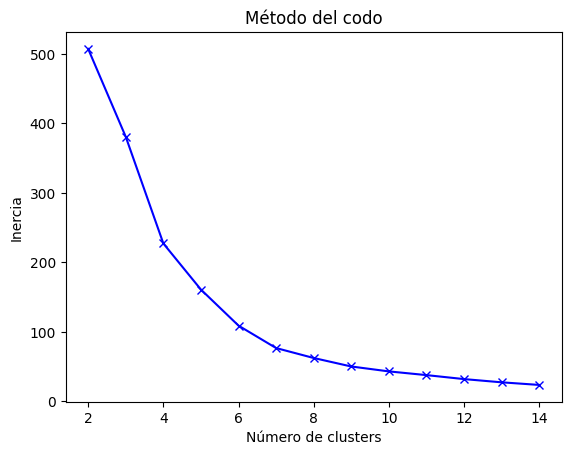

In [144]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
K = range(2, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.plot(K, inercia, "bx-")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

In [145]:
k_optimo = 7
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
df_final["cluster"] = kmeans.fit_predict(X_scaled)

In [146]:
df_clusters = df_final.drop(columns="id_cliente").groupby("cluster").mean()
print(df_clusters)

         valorRedemption     valorSale    recencia   frecuencia
cluster                                                        
0           1.899018e+04  4.607742e+06   69.052632    56.719298
1           1.498543e+06  1.502434e+08    1.500000   713.000000
2           2.066756e+05  2.206960e+07   45.200000   603.333333
3           0.000000e+00  1.201652e+05  556.125000     4.062500
4           0.000000e+00  2.667379e+08    1.000000   310.000000
5           3.249112e+06  1.953477e+08    8.000000  1951.000000
6           9.097818e+02  6.443579e+05  292.381818    15.272727


In [147]:
clust_count = df_final["cluster"].value_counts()

In [148]:
clust_count = clust_count.reset_index()

In [149]:
clust_count.merge(df_clusters, how="left", on=["cluster"]).round(2).set_index("cluster")

,count,valorRedemption,valorSale,recencia,frecuencia
cluster,,,,,
0,114,18990.18,4.607742e+06,69.05,56.72
6,55,909.78,6.443579e+05,292.38,15.27
3,32,0.00,1.201652e+05,556.12,4.06
2,15,206675.60,2.206960e+07,45.20,603.33
1,2,1498543.00,1.502434e+08,1.50,713.00
5,1,3249112.00,1.953477e+08,8.00,1951.00
4,1,0.00,2.667379e+08,1.00,310.00
